# Modelo estático: CAPM

En este ejercicio estimaremos el beta CAPM para varias acciones. El modelo CAPM 

In [1]:
library(dplyr)
library(ggpubr)
library(tsibble)
library(feasts)
library(tidyquant)
library(ggplot2)
library(ggtime)
library(moments)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Warning message:
package ‘dplyr’ was built under R version 4.5.3 


Loading required package: ggplot2


Warning message:
package ‘ggpubr’ was built under R version 4.5.3 



Attaching package: ‘tsibble’

The following objects are masked from ‘package:base’:

    intersect, setdiff, union



...

Loading required package: fabletools


Warning messages:
1: package ‘feasts’ was built under R version 4.5.3 
2: package ‘fabletools’ was built under R version 4.5.3 


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 
── Attaching core tidyquant packages ────────────────────────────────────────────────────────────── tidyquant 1.0.12 ──
✔ PerformanceAnalytics 2.1.0      ✔ TTR                  0.24.4
✔ quantmod             0.4.29     ✔ xts                  0.14.2
── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ dplyr::filter()                masks stats::filter()
✖ xts::first()                   masks dplyr::first()
✖ zoo::index()                   masks tsibble::index()
✖ dplyr::lag()                   masks stats::lag()
✖ xts::last()                    masks dplyr::last()
✖ PerformanceAnalytics::legend() masks graphics::legend()
✖ quantmod::summary()            masks base::summary()
ℹ Use the ]8;;http://conflicted.

Warning messages:
1: package ‘tidyquant’ was built under R version 4.5.3 
2: package ‘xts’ was built under R version 4.5.3 
3: package ‘quantmod’ was built under R version 4.5.3 
4: package ‘TTR’ was built under R version 4.5.3 
5: package ‘PerformanceAnalytics’ was built under R version 4.5.3 
Warning message:
package ‘ggtime’ was built under R version 4.5.3 



Attaching package: ‘moments’

The following objects are masked from ‘package:PerformanceAnalytics’:

    kurtosis, skewness



In [3]:
library(lubridate)
pg<-tq_get("PG", get = "stock.prices",from="2022-01-01")|>select(date, adjusted)
pg<-pg|>mutate(day=ymd(date))|>as_tsibble(index=day)

nvda<-tq_get("NVDA", get = "stock.prices",from="2022-01-01")|>select(date, adjusted)
nvda<-nvda|>mutate(day=ymd(date))|>as_tsibble(index=day)

irx<-tq_get("^IRX", get = "stock.prices",from="2022-01-01")|>select(date, adjusted)
irx<-irx|>mutate(day=ymd(date))|>as_tsibble(index=day)

sp<-tq_get("^GSPC", get = "stock.prices",from="2022-01-01")|>select(date, adjusted)
sp<-sp|>mutate(day=ymd(date))|>as_tsibble(index=day)


Attaching package: ‘lubridate’

The following object is masked from ‘package:tsibble’:

    interval

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Warning message:
package ‘lubridate’ was built under R version 4.5.3 


In [4]:
pg<-pg|>mutate(r=log(adjusted)-lag(log(adjusted)))
nvda<-nvda|>mutate(r=log(adjusted)-lag(log(adjusted)))
sp<-sp|>mutate(r=log(adjusted)-lag(log(adjusted)))

- Primero veamos el comportamiento de los precios

Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
3: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
4: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
5: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
6: Removed 2 rows containing missing values or values outside the scale range (`geom_line()`). 
7: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 


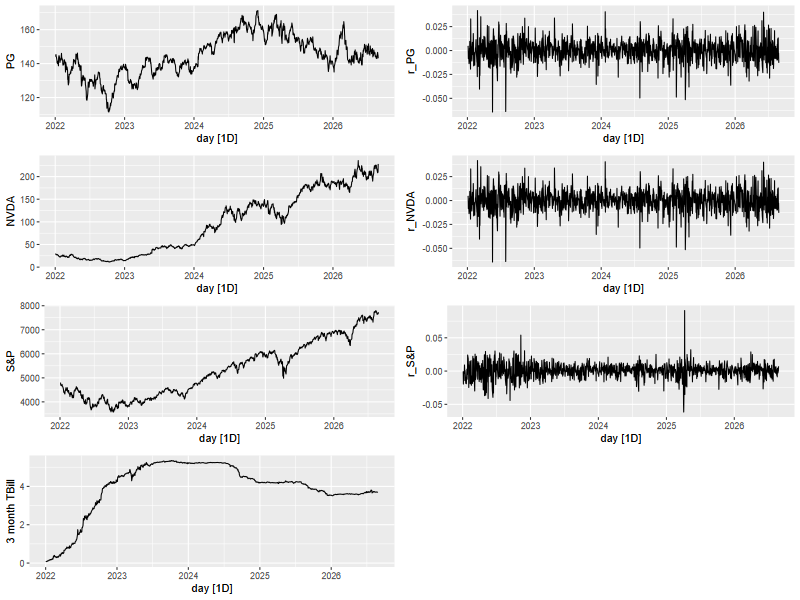

In [5]:
pg.plot<-pg|>autoplot(adjusted)+labs(y="PG")
rpg.plot<-pg|>autoplot(r)+labs(y="r_PG")
nvda.plot<-nvda|>autoplot(adjusted)+labs(y="NVDA")
rnvda.plot<-pg|>autoplot(r)+labs(y="r_NVDA")
sp.plot<-sp|>autoplot(adjusted)+labs(y="S&P")
rsp.plot<-sp|>autoplot(r)+labs(y="r_S&P")
tbill.plot<-irx|>autoplot(adjusted)+labs(y="3 month TBill")

ggarrange(pg.plot,rpg.plot,
nvda.plot,rnvda.plot,
sp.plot, rsp.plot,
tbill.plot,
ncol=2,nrow=4)

- Agregamos a retornos mensuales

In [6]:
pg_mes<-pg|>index_by(mes=~yearmonth(.))|>summarise(r=sum(r,na.rm=TRUE),.groups="drop")
nvda_mes<-nvda|>index_by(mes=~yearmonth(.))|>summarise(r=sum(r,na.rm=TRUE),.groups="drop")
sp_mes<-sp|>index_by(mes=~yearmonth(.))|>summarise(r=sum(r,na.rm=TRUE),.groups="drop")
irx_mes<-irx|>index_by(mes=~yearmonth(.))|>summarise(rf=
  0.01*(mean(adjusted,na.rm=TRUE)),.groups="drop")

- Creamos los excesos de retorno. Para ello debemos anualizar los retornos logaritmicos de PG y NVDA. Las tasas de los T-Bill están anualizadas. A partir de ello creamos el exceso de retorno

In [7]:
pg_mes<-pg_mes|>mutate(r_a=r*12)
nvda_mes<-nvda_mes|>mutate(r_a=r*12)
sp_mes<-sp_mes|>mutate(r_a=r*12)

In [8]:
rpg<-pg_mes$r_a-irx_mes$rf
rnvda<-nvda_mes$r_a-irx_mes$rf
rsp<-sp_mes$r_a-irx_mes$rf

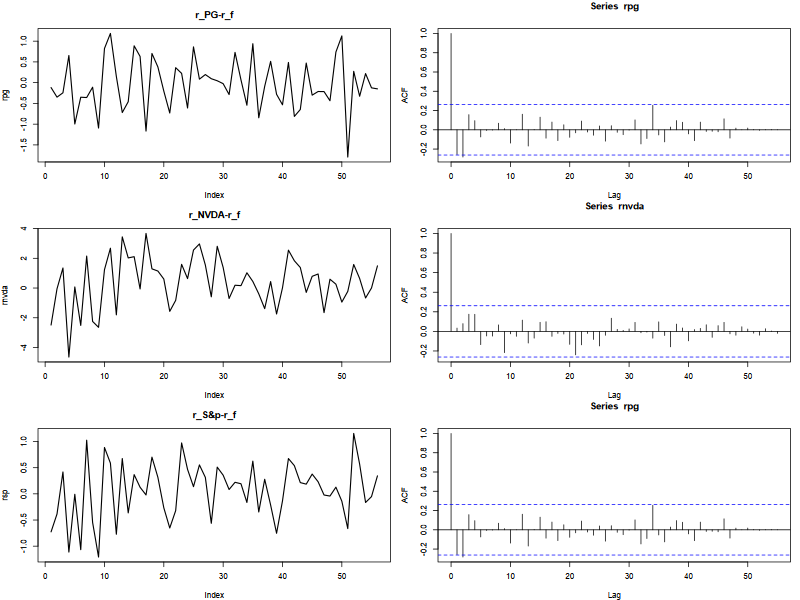

In [9]:
par(mfrow = c(3, 2), mar = c(4, 4, 3, 1))
plot(rpg,main="r_PG-r_f",type="l",lwd = 1.5)
acf(rpg, "r_PG-r_f")
plot(rnvda,main="r_NVDA-r_f",type="l",lwd = 1.5)
acf(rnvda, "r_NVDA-r_f")
plot(rsp,main="r_S&p-r_f",type="l",lwd = 1.5)
acf(rpg, "r_SP-r_f")
par(mfrow = c(1, 1))

- Corremos el modelo. Estimamos por MCO

In [10]:
beta_pg<-lm(rpg~rsp)
summary(beta_pg)


Call:
lm(formula = rpg ~ rsp)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.50117 -0.38223 -0.04909  0.47224  1.23689 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept) -0.06262    0.08048  -0.778   0.4399  
rsp          0.34395    0.14777   2.328   0.0237 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5982 on 54 degrees of freedom
Multiple R-squared:  0.09118,	Adjusted R-squared:  0.07435 
F-statistic: 5.418 on 1 and 54 DF,  p-value: 0.02371


In [11]:
beta_nvda<-lm(rnvda~rsp)
summary(beta_nvda)


Call:
lm(formula = rnvda ~ rsp)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.2845 -0.6295 -0.1390  0.6096  3.4711 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.2477     0.1495   1.656    0.103    
rsp           2.3452     0.2746   8.541 1.33e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.112 on 54 degrees of freedom
Multiple R-squared:  0.5747,	Adjusted R-squared:  0.5668 
F-statistic: 72.95 on 1 and 54 DF,  p-value: 1.332e-11


- Es común encontrar medidas obtenidas sin usar el exceso de retorno. Veamos la diferencia

In [12]:
beta_pg_no_rf<-lm(pg_mes$r~sp_mes$r)
summary(beta_pg_no_rf)


Call:
lm(formula = pg_mes$r ~ sp_mes$r)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.124859 -0.031903 -0.003818  0.039522  0.102998 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept) -0.003118   0.006785  -0.459   0.6477  
sp_mes$r     0.351019   0.146762   2.392   0.0203 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.04991 on 54 degrees of freedom
Multiple R-squared:  0.09579,	Adjusted R-squared:  0.07904 
F-statistic:  5.72 on 1 and 54 DF,  p-value: 0.02028


In [13]:
beta_nvda_no_rf<-lm(nvda_mes$r~sp_mes$r)
summary(beta_nvda_no_rf)


Call:
lm(formula = nvda_mes$r ~ sp_mes$r)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.190715 -0.053953 -0.009728  0.052628  0.288005 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.01618    0.01254   1.291    0.202    
sp_mes$r     2.34856    0.27113   8.662 8.55e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0922 on 54 degrees of freedom
Multiple R-squared:  0.5815,	Adjusted R-squared:  0.5737 
F-statistic: 75.03 on 1 and 54 DF,  p-value: 8.551e-12


## Actividad

- Si fuera un asesor de inversiones, ¿que recomendaría basado en los valores $\hat{\beta}$ estimados?
- Para cada uno de los modelos, obtenga los residuales y realice la gráfica de ACF ¿Hay evidencia de autocorrelación serial? ¿Por qué es importante que los residuales no estén autocorrelacionados?
- Elija una acción diferente y replique el ejercicio
- Para cada uno de las acciones, calcule el ratio de Sharpe. Inteprete los valores y compare entre los activos